# Phase 2 — Baseline z-score strategy (walk-forward, gross of costs)

- spread_t = A_t − beta_d · B_t, where beta_d is re-estimated **each morning** on the previous `HEDGE_LOOKBACK_DAYS` days
- z_t = (spread_t − rolling mean) / rolling std over `ZSCORE_WINDOW` bars ending at t
- long spread if z < −2, short spread if z > +2, exit when z crosses back through 0
- signal on the close of bar t, fill on the close of bar t+1; no new entries after 14:50, flatten signal at 15:05 (filled 15:10), since NSE retail intraday can't carry shorts overnight
- dollar-neutral sizing: ₹`NOTIONAL_PER_LEG` long one leg, ₹`NOTIONAL_PER_LEG` short the other

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))   # make /src importable

import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
%matplotlib inline

In [2]:
from data_pipeline import load_universe, split_formation_trading
from cointegration import FORMATION_DAYS, screen_pairs, select_pairs_for_trading

universe = load_universe()                      # cached parquet in /data; refresh=True to re-download
formation = {k: split_formation_trading(v, FORMATION_DAYS)[0] for k, v in universe.items()}
phase1 = screen_pairs(formation)
selected, used_fallback = select_pairs_for_trading(phase1)
PAIR = selected[0]
prices = universe[PAIR]
trade_start = split_formation_trading(prices, FORMATION_DAYS)[1].index[0]
print(f"Trading pair: {PAIR}   fallback used: {used_fallback}   trading period starts {trade_start}")

Trading pair: SBIN/BANKBARODA   fallback used: True   trading period starts 2026-07-30 09:15:00+05:30


In [3]:
import strategy as st
print({k: getattr(st, k) for k in ["ZSCORE_WINDOW", "ENTRY_Z", "EXIT_Z", "HEDGE_LOOKBACK_DAYS", "CAPITAL",
                                    "NOTIONAL_PER_LEG", "SIZING_MODE", "EXECUTION_LAG_BARS",
                                    "NO_NEW_ENTRY_AFTER", "EOD_EXIT_TIME"]})

{'ZSCORE_WINDOW': 60, 'ENTRY_Z': 2.0, 'EXIT_Z': 0.0, 'HEDGE_LOOKBACK_DAYS': 10, 'CAPITAL': 1000000, 'NOTIONAL_PER_LEG': 500000, 'SIZING_MODE': 'dollar_neutral', 'EXECUTION_LAG_BARS': 1, 'NO_NEW_ENTRY_AFTER': '14:50', 'EOD_EXIT_TIME': '15:05'}


## 1. Walk-forward hedge ratio and z-score
Plotting beta over time shows **why** it must be re-estimated. If the hedge ratio drifts a lot, a single full-sample beta would have used future information *and* would have been wrong for most of the sample.

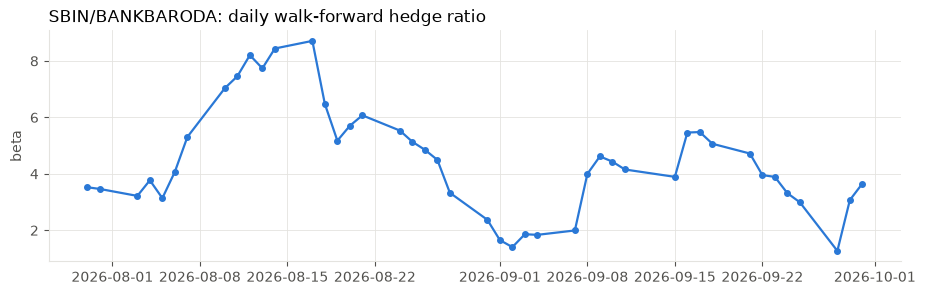

,count,mean,std,min,25%,50%,75%,max
beta,3200.0,4.451188,1.870485,1.269562,3.314974,4.072850,5.462859,8.710855
spread,3200.0,-49.643780,449.956540,-1095.785454,-292.236617,47.550024,247.399694,697.679921
zscore,3200.0,-0.011576,1.426135,-5.292036,-1.068686,-0.060206,1.066251,5.340055


In [4]:
from strategy import build_signals
from backtest_report import SERIES_COLORS, _session_axis

sig = build_signals(prices, trade_start=trade_start)
daily_beta = sig["beta"].groupby(sig.index.normalize()).first()
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(daily_beta.index, daily_beta.values, color=SERIES_COLORS[0], marker="o", ms=4)
ax.set_title(f"{PAIR}: daily walk-forward hedge ratio", loc="left"); ax.set_ylabel("beta")
plt.show()
sig[["beta", "spread", "zscore"]].describe().T

## 2. Backtest (no costs)

In [5]:
from strategy import run_backtest
from backtest_report import compute_metrics, comparison_table, format_table

gross = run_backtest(sig, label="z-score (gross)")
format_table(comparison_table([gross]))

,z-score (gross)
Total return,1.29%
Annualised return,7.60%
Annualised excess return,1.10%
Annualised volatility,4.38%
Sharpe ratio,0.26
Max drawdown,-1.48%
Number of trades,59
Win rate,64.41%
Avg holding (bars),29.78
Avg holding (minutes),148.90


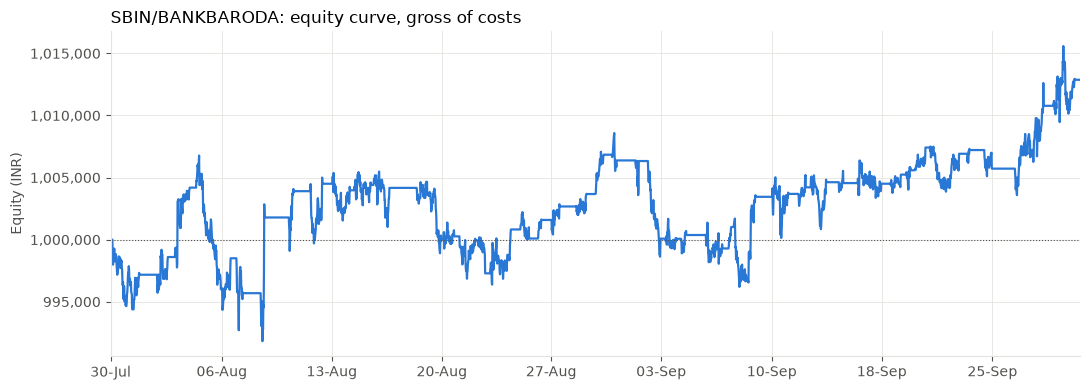

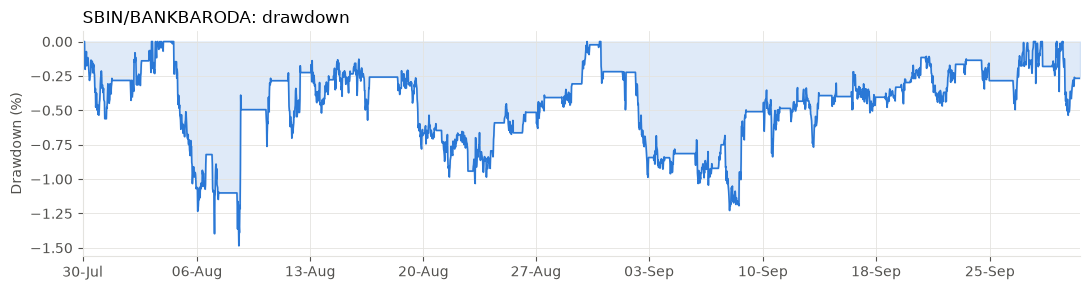

In [6]:
from backtest_report import plot_equity, plot_drawdown, plot_zscore_signals, plot_trade_pnl
plot_equity([gross], f"{PAIR}: equity curve, gross of costs"); plt.show()
plot_drawdown([gross], f"{PAIR}: drawdown"); plt.show()

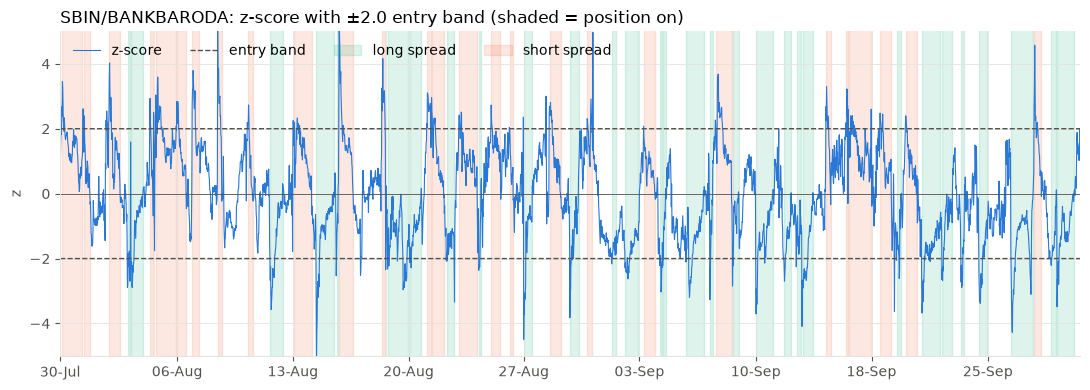

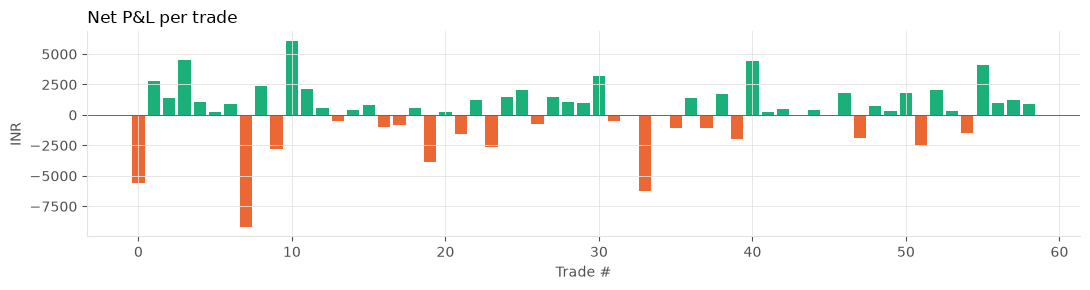

In [7]:
plot_zscore_signals(gross, f"{PAIR}: z-score with ±{st.ENTRY_Z} entry band (shaded = position on)"); plt.show()
plot_trade_pnl(gross); plt.show()

## 3. Trade diagnostics
`exit_reason` tells us whether trades closed because the spread **actually reverted** (`signal`) or because the day ran out (`eod` = scheduled 15:05 flatten, `session_end` = safety close when the day's data ended early). A high share of time-based exits means the spread's half-life is too long for an intraday horizon.

In [8]:
t = gross.trades
display(t["exit_reason"].value_counts().to_frame("trades"))
display(t.groupby("exit_reason")[["gross_pnl", "bars_held"]].mean().round(1))
t[["entry_time", "exit_time", "direction", "entry_z", "shares_a", "shares_b", "bars_held", "exit_reason", "gross_pnl"]].head(10)

,trades
exit_reason,
signal,33
eod,26


,gross_pnl,bars_held
exit_reason,,
eod,-1029.2,31.0
signal,1201.0,28.8


,entry_time,exit_time,direction,entry_z,shares_a,shares_b,bars_held,exit_reason,gross_pnl
0,2026-07-30 09:45:00+05:30,2026-07-30 15:10:00+05:30,-1,2.672392,-493,2072,65,eod,-5609.500916
1,2026-07-31 09:20:00+05:30,2026-07-31 10:55:00+05:30,-1,2.399273,-484,2058,19,signal,2783.205536
2,2026-08-03 09:30:00+05:30,2026-08-03 12:30:00+05:30,-1,2.176183,-483,2044,36,signal,1426.182495
3,2026-08-03 14:25:00+05:30,2026-08-03 15:10:00+05:30,1,-2.892535,481,-2023,9,eod,4494.505569
4,2026-08-04 09:20:00+05:30,2026-08-04 12:30:00+05:30,1,-2.006545,482,-2026,38,signal,1092.536041
5,2026-08-04 14:15:00+05:30,2026-08-04 15:10:00+05:30,-1,2.402680,-481,2032,11,eod,213.766357
6,2026-08-05 09:20:00+05:30,2026-08-05 09:25:00+05:30,-1,2.371562,-479,2007,1,signal,894.073944
7,2026-08-05 09:50:00+05:30,2026-08-05 15:10:00+05:30,-1,3.040829,-478,2009,64,eod,-9210.914566
8,2026-08-06 09:20:00+05:30,2026-08-06 11:40:00+05:30,-1,2.488248,-472,2025,28,signal,2414.910049
9,2026-08-06 13:15:00+05:30,2026-08-06 15:10:00+05:30,-1,2.669834,-466,2015,23,eod,-2810.096619


## 4. Context: all candidate pairs
For honesty, run the same engine on every candidate, including the ones that failed Phase 1. If the failed pairs perform just as well (or badly) as the "selected" one, the cointegration screen isn't adding information on this sample.

In [9]:
rows = []
for k, px in universe.items():
    ts = split_formation_trading(px, FORMATION_DAYS)[1].index[0]
    r = run_backtest(build_signals(px, trade_start=ts), label=k)
    rows.append(r)
format_table(comparison_table(rows))

,HDFCBANK/ICICIBANK,TCS/INFY,SBIN/BANKBARODA
Total return,-0.26%,-1.83%,1.29%
Annualised return,-1.47%,-10.03%,7.60%
Annualised excess return,-7.97%,-16.53%,1.10%
Annualised volatility,6.40%,5.80%,4.38%
Sharpe ratio,-1.18,-2.88,0.26
Max drawdown,-4.06%,-3.72%,-1.48%
Number of trades,52,52,59
Win rate,48.08%,61.54%,64.41%
Avg holding (bars),35.21,34.54,29.78
Avg holding (minutes),176.06,172.69,148.90
